## Testing new Cov matrix code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import sys

esmDMS_DIR = "/Users/dylanwells/popDMS/esmDMS"

sys.path.insert(0, esmDMS_DIR)
from esmdmsfunctions import (
    get_eigenvector_simulation_results,
    get_simulation_results,
    generate_selection, gaussian_selection, zero_selection,
    z_normalize, load_final_df,
)
from scipy.stats import pearsonr


In [2]:
import os

# ── Paths to analyse (name → directory containing layer0/, layer1/, … subdirs)
comb_path = esmDMS_DIR + "/data/bg_bf_comb_data"
bg_path   = esmDMS_DIR + "/data/inference_data/BG505"
bf_path   = esmDMS_DIR + "/data/inference_results"

PATHS = {
    #"comb":  comb_path,
    "BG505": bg_path,
    "BF520": bf_path,
}

# ── Layers to analyze
LAYERS = [0, 12, 30]#range()

# ── Simulation parameters
N_GENS      = 30      # number of generations to simulate
SAVE_EVERY  = 1       # save counts every N generations
FITNESS_FN  = 'exp'   # 'plus1' or 'exp'

# ── Eigenvector / PCA parameters
VARIANCE_EXPLAINED_CUTOFF = 0.8   # keep PCs that together explain this fraction of variance
WEIGHT_BY_INITIAL_FREQ    = False  # weight covariance matrix by pre-selection counts

# ── Selection function (generate_selection, gaussian_selection, or zero_selection)
SEL_FUNC = gaussian_selection

# ── Inference flags
RUN_INFERENCE    = True
RUN_GAMMA        = False
CALC_ERROR_BARS  = False
INFER_IGNORED    = True

In [9]:
all_results = {}   # path_name -> (all_layer_fits, all_sel_coeffs, detailed_results, gamma_results, all_gen_counts, eig_info)

PATHS = {
    #"comb":  comb_path,
    "BG505": bg_path,
    "BF520": bf_path,
}

for path_name, path in PATHS.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {path_name}  |  {path}")
    print('='*60)

    results = get_eigenvector_simulation_results(
        n_gens=N_GENS,
        embedding_df_path=path,
        sel_func=SEL_FUNC,
        inference=RUN_INFERENCE,
        gamma_analysis=RUN_GAMMA,
        fitness=FITNESS_FN,
        save_every=SAVE_EVERY,
        layers=LAYERS,
        variance_explained_cutoff=VARIANCE_EXPLAINED_CUTOFF,
        weight_by_initial_freq=WEIGHT_BY_INITIAL_FREQ,
        calc_error_bars=CALC_ERROR_BARS,
        infer_ignored_dims=INFER_IGNORED,
    )
    all_results[path_name] = results

print("\nDone. Datasets completed:", list(all_results.keys()))



Dataset: BG505  |  /Users/dylanwells/popDMS/esmDMS/data/inference_data/BG505
Running layer 0...
  Layer 0: keeping 12/640 eigenvectors (80.2% variance explained)
  Running simulation...
  Running inference for layer 0 (method='independent')...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...


KeyboardInterrupt: 

## Diagonal method (Approach 1)

In [ ]:
results_diagonal = {}

for path_name, path in PATHS.items():
    print(f"
{chr(61)*60}")
    print(f"Dataset: {path_name}  |  method=diagonal")
    print(chr(61)*60)

    results_diagonal[path_name] = get_eigenvector_simulation_results(
        n_gens=N_GENS,
        embedding_df_path=path,
        sel_func=SEL_FUNC,
        inference=RUN_INFERENCE,
        gamma_analysis=RUN_GAMMA,
        fitness=FITNESS_FN,
        save_every=SAVE_EVERY,
        layers=LAYERS,
        variance_explained_cutoff=VARIANCE_EXPLAINED_CUTOFF,
        weight_by_initial_freq=WEIGHT_BY_INITIAL_FREQ,
        calc_error_bars=True,
        infer_ignored_dims=INFER_IGNORED,
        method="diagonal",
    )

print("
Done. Datasets completed:", list(results_diagonal.keys()))

## Full covariance method (Approach 2)

In [ ]:
results_fullcov = {}

for path_name, path in PATHS.items():
    print(f"
{chr(61)*60}")
    print(f"Dataset: {path_name}  |  method=fullcov")
    print(chr(61)*60)

    results_fullcov[path_name] = get_eigenvector_simulation_results(
        n_gens=N_GENS,
        embedding_df_path=path,
        sel_func=SEL_FUNC,
        inference=RUN_INFERENCE,
        gamma_analysis=RUN_GAMMA,
        fitness=FITNESS_FN,
        save_every=SAVE_EVERY,
        layers=LAYERS,
        variance_explained_cutoff=VARIANCE_EXPLAINED_CUTOFF,
        weight_by_initial_freq=WEIGHT_BY_INITIAL_FREQ,
        calc_error_bars=True,
        infer_ignored_dims=INFER_IGNORED,
        method="fullcov",
    )

print("
Done. Datasets completed:", list(results_fullcov.keys()))

## Compare inferred selection coefficients across methods

In [ ]:
# For each dataset and layer, correlate s_joint from each method pair.
# Results are indexed as: results[path_name] = (layer_fits, sel_coeffs, detailed, gamma, gen_counts, eig_info)
# detailed[layer] = [s, s_joint, s_errors, s_joint_errors]

method_results = {
    "independent": all_results,
    "diagonal":    results_diagonal,
    "fullcov":     results_fullcov,
}

pairs = [("independent", "diagonal"), ("independent", "fullcov"), ("diagonal", "fullcov")]

for path_name in PATHS:
    print(f"
Dataset: {path_name}")
    true_s = {}  # method -> stacked s_joint across layers
    for method_name, res_dict in method_results.items():
        detailed = res_dict[path_name][2]  # index 2 = detailed_selection_results
        s_joint_layers = np.concatenate([detailed[l][1].flatten() for l in LAYERS if l in detailed])
        true_s[method_name] = s_joint_layers
    for m1, m2 in pairs:
        if m1 in true_s and m2 in true_s:
            r, _ = pearsonr(true_s[m1], true_s[m2])
            print(f"  {m1} vs {m2}: r = {r:.4f}")

## Compare inferred vs true selection coefficients

In [ ]:
# For each dataset and layer, correlate s_joint with the true selection coefficients.

for path_name in PATHS:
    print(f"
Dataset: {path_name}")
    for method_name, res_dict in method_results.items():
        all_sel_coeffs = res_dict[path_name][1]   # true sel coeffs (in PCA space)
        detailed       = res_dict[path_name][2]   # detailed inference results
        rs = []
        for l in LAYERS:
            if l not in detailed or l not in all_sel_coeffs:
                continue
            s_true  = all_sel_coeffs[l].flatten()
            s_infer = detailed[l][1].flatten()  # s_joint
            if len(s_true) != len(s_infer):
                continue
            r, _ = pearsonr(s_true, s_infer)
            rs.append(r)
        if rs:
            print(f"  {method_name}: mean r(true, inferred) = {np.mean(rs):.4f} +/- {np.std(rs):.4f}")

---
## Analysis: comparing the three inference methods (get_simulation_results)

### Run the baseline independent method with error bars enabled

In [3]:
sim_results_independent = {}

for path_name, path in PATHS.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {path_name}  |  get_simulation_results, method=independent")
    print('='*60)

    sim_results_independent[path_name] = get_simulation_results(
        n_gens=N_GENS,
        embedding_df_path=path,
        sel_func=SEL_FUNC,
        inference=RUN_INFERENCE,
        gamma_analysis=RUN_GAMMA,
        fitness=FITNESS_FN,
        save_every=SAVE_EVERY,
        layers=LAYERS,
        calc_error_bars=True,
        infer_ignored_dims=INFER_IGNORED,
        method='independent',
    )

print("\nDone. Datasets completed:", list(sim_results_independent.keys()))



Dataset: BG505  |  get_simulation_results, method=independent
Running layer 0...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...


/Users/dylanwells/popDMS/esmDMS/popDMS.py:1499: RuntimeWarning: invalid value encountered in sqrt
  err_sub[r_idx] = np.sqrt(np.diag(np.linalg.inv(reg)))
/Users/dylanwells/popDMS/esmDMS/popDMS.py:1506: RuntimeWarning: invalid value encountered in sqrt
  s_joint_err_sub = np.sqrt(np.diag(np.linalg.inv(reg_joint)))


Running layer 12...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...
Running layer 30...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...


/Users/dylanwells/popDMS/esmDMS/popDMS.py:1499: RuntimeWarning: invalid value encountered in sqrt
  err_sub[r_idx] = np.sqrt(np.diag(np.linalg.inv(reg)))
/Users/dylanwells/popDMS/esmDMS/popDMS.py:1506: RuntimeWarning: invalid value encountered in sqrt
  s_joint_err_sub = np.sqrt(np.diag(np.linalg.inv(reg_joint)))



Dataset: BF520  |  get_simulation_results, method=independent
Running layer 0...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...
Running layer 12...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...


/Users/dylanwells/popDMS/esmDMS/popDMS.py:1499: RuntimeWarning: invalid value encountered in sqrt
  err_sub[r_idx] = np.sqrt(np.diag(np.linalg.inv(reg)))
/Users/dylanwells/popDMS/esmDMS/popDMS.py:1506: RuntimeWarning: invalid value encountered in sqrt
  s_joint_err_sub = np.sqrt(np.diag(np.linalg.inv(reg_joint)))


Running layer 30...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...

Done. Datasets completed: ['BG505', 'BF520']


/Users/dylanwells/popDMS/esmDMS/popDMS.py:1499: RuntimeWarning: invalid value encountered in sqrt
  err_sub[r_idx] = np.sqrt(np.diag(np.linalg.inv(reg)))
/Users/dylanwells/popDMS/esmDMS/popDMS.py:1506: RuntimeWarning: invalid value encountered in sqrt
  s_joint_err_sub = np.sqrt(np.diag(np.linalg.inv(reg_joint)))


### Run diagonal method with error bars enabled

In [4]:
sim_results_diagonal_eb = {}

for path_name, path in PATHS.items():
    print()
    print("=" * 60)
    print(f"Dataset: {path_name}  |  get_simulation_results, method=diagonal")
    print("=" * 60)

    sim_results_diagonal_eb[path_name] = get_simulation_results(
        n_gens=N_GENS,
        embedding_df_path=path,
        sel_func=SEL_FUNC,
        inference=RUN_INFERENCE,
        gamma_analysis=RUN_GAMMA,
        fitness=FITNESS_FN,
        save_every=SAVE_EVERY,
        layers=LAYERS,
        calc_error_bars=True,
        infer_ignored_dims=INFER_IGNORED,
        method="diagonal",
    )

print("Done. Datasets completed:", list(sim_results_diagonal_eb.keys()))



Dataset: BG505  |  get_simulation_results, method=diagonal
Running layer 0...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='diagonal')...
Running layer 12...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='diagonal')...
Running layer 30...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='diagonal')...

Dataset: BF520  |  get_simulation_results, method=diagonal
Running layer 0...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='diagonal')...
Running layer 12...
Running simulation...
  Analyzing generati

### Run full covariance method with error bars enabled

In [5]:
sim_results_fullcov_eb = {}

for path_name, path in PATHS.items():
    print()
    print("=" * 60)
    print(f"Dataset: {path_name}  |  get_simulation_results, method=fullcov")
    print("=" * 60)

    sim_results_fullcov_eb[path_name] = get_simulation_results(
        n_gens=N_GENS,
        embedding_df_path=path,
        sel_func=SEL_FUNC,
        inference=RUN_INFERENCE,
        gamma_analysis=RUN_GAMMA,
        fitness=FITNESS_FN,
        save_every=SAVE_EVERY,
        layers=LAYERS,
        calc_error_bars=True,
        infer_ignored_dims=INFER_IGNORED,
        method="fullcov",
    )

print("Done. Datasets completed:", list(sim_results_fullcov_eb.keys()))



Dataset: BG505  |  get_simulation_results, method=fullcov
Running layer 0...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...
Running layer 12...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...
Running layer 30...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...

Dataset: BF520  |  get_simulation_results, method=fullcov
Running layer 0...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...
Running layer 12...
Running simulation...
  Analyzing generation 30.

### Setup: collect results and pre-compute metrics

In [6]:
SIM_ALL = {
    'independent': sim_results_independent,
    'diagonal':    sim_results_diagonal_eb,
    'fullcov':     sim_results_fullcov_eb,
}
METHOD_COLORS = {
    'independent': '#4C72B0',
    'diagonal':    '#DD8452',
    'fullcov':     '#55A868',
}
METHOD_LABELS = {
    'independent': 'Independent (original)',
    'diagonal':    'Diagonal (Approach 1)',
    'fullcov':     'Full cov (Approach 2)',
}
LAYERS_LIST = sorted(LAYERS)
DATASETS    = list(PATHS.keys())
METHODS     = list(SIM_ALL.keys())

# Load embeddings once per dataset x layer to avoid re-reading for each method
print("Loading embeddings cache...")
emb_cache = {}
for path_name, path in PATHS.items():
    for l in LAYERS_LIST:
        try:
            df_sel = load_final_df(l, path)
            emb_cache[(path_name, l)] = np.vstack(df_sel['Embedding'].values)
        except Exception as e:
            print(f"  Warning: {path_name} layer {l}: {e}")
print(f"Cached {len(emb_cache)} (dataset, layer) pairs.")

# Pre-compute per-method/dataset/layer metrics
nan_frac  = {m: {p: [] for p in DATASETS} for m in METHODS}
mean_mag  = {m: {p: [] for p in DATASETS} for m in METHODS}
r_s       = {m: {p: [] for p in DATASETS} for m in METHODS}
r_fitness = {m: {p: [] for p in DATASETS} for m in METHODS}

for method in METHODS:
    for path_name in DATASETS:
        res        = SIM_ALL[method][path_name]
        true_s_d   = res[1]   # all_selection_coefficients
        detailed   = res[2]   # detailed_selection_results
        true_fits  = res[0]   # all_layer_fits

        for l in LAYERS_LIST:
            if l not in detailed:
                for d in [nan_frac, mean_mag, r_s, r_fitness]:
                    d[method][path_name].append(np.nan)
                continue

            # --- error bars ---
            errs = detailed[l][3]   # s_joint_errors
            if errs is None:
                nan_frac[method][path_name].append(1.0)
                mean_mag[method][path_name].append(np.nan)
            else:
                nan_frac[method][path_name].append(float(np.mean(np.isnan(errs))))
                valid = np.abs(errs[~np.isnan(errs)])
                mean_mag[method][path_name].append(float(np.mean(valid)) if len(valid) > 0 else np.nan)

            # --- s correlation ---
            if l in true_s_d:
                s_true  = true_s_d[l].flatten()
                s_infer = detailed[l][1].flatten()
                mask    = ~np.isnan(s_infer)
                if mask.sum() > 1:
                    r_s[method][path_name].append(
                        float(pearsonr(s_true[mask], s_infer[mask]).statistic))
                else:
                    r_s[method][path_name].append(np.nan)
            else:
                r_s[method][path_name].append(np.nan)

            # --- fitness correlation ---
            key = (path_name, l)
            if key in emb_cache and l in true_fits:
                embeddings = emb_cache[key]
                s_joint    = detailed[l][1]
                s_clean    = np.where(np.isnan(s_joint), 0.0, s_joint)
                inf_fit    = np.exp(np.clip(embeddings @ s_clean, -50, 50))
                tru_fit    = true_fits[l]
                if len(inf_fit) == len(tru_fit) and np.all(np.isfinite(inf_fit)):
                    r_fitness[method][path_name].append(
                        float(pearsonr(tru_fit, inf_fit).statistic))
                else:
                    r_fitness[method][path_name].append(np.nan)
            else:
                r_fitness[method][path_name].append(np.nan)

print("Pre-computation complete.")


Loading embeddings cache...
Cached 6 (dataset, layer) pairs.
Pre-computation complete.


### Figure 1: Error bar diagnostics (NaN fraction and magnitude)

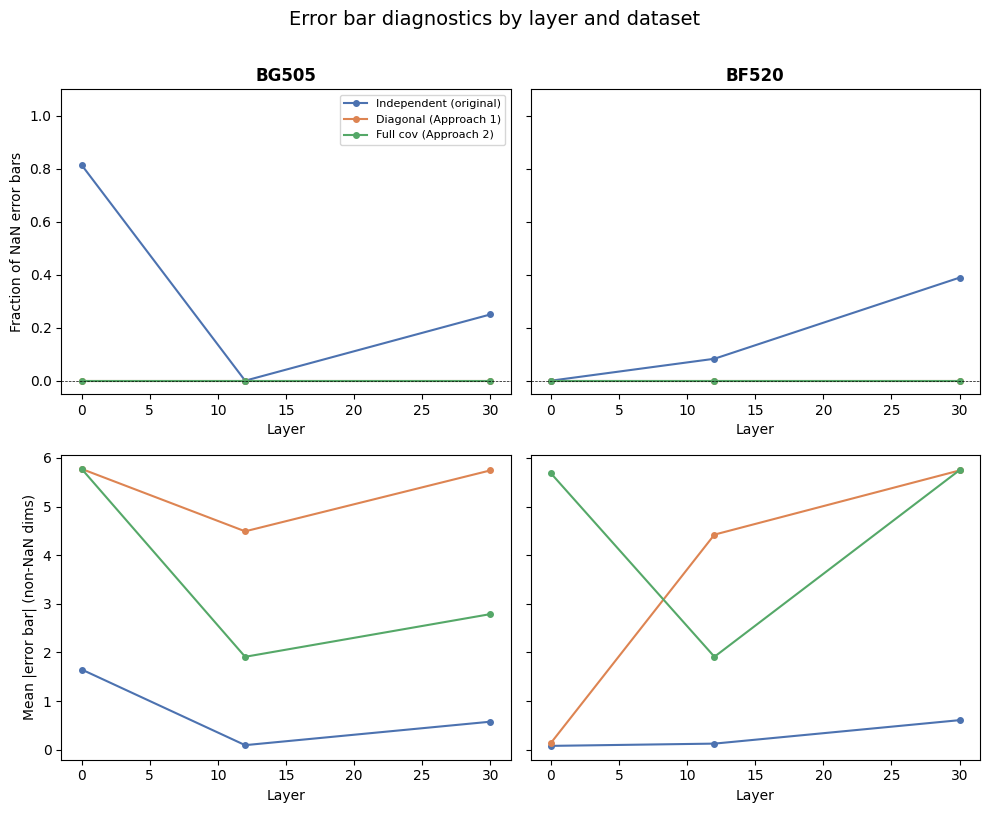


Total NaN error bars per method/dataset (NaN dims / total dims across all layers):
Method                     BG505           BF520         
---------------------------------------------------------
independent                   681/1920         302/1920    
diagonal                        0/1920           0/1920    
fullcov                         0/1920           0/1920    


In [7]:
fig, axes = plt.subplots(2, len(DATASETS), figsize=(5 * len(DATASETS), 8), sharey='row')
fig.suptitle("Error bar diagnostics by layer and dataset", fontsize=14, y=1.01)

for di, path_name in enumerate(DATASETS):
    # Row 0: NaN fraction
    ax = axes[0, di]
    for method in METHODS:
        ax.plot(LAYERS_LIST, nan_frac[method][path_name],
                marker='o', ms=4, lw=1.5,
                label=METHOD_LABELS[method], color=METHOD_COLORS[method])
    ax.set_title(path_name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Layer")
    ax.set_ylim(-0.05, 1.1)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    if di == 0:
        ax.set_ylabel("Fraction of NaN error bars")
        ax.legend(fontsize=8)

    # Row 1: Mean magnitude of non-NaN error bars
    ax = axes[1, di]
    for method in METHODS:
        ax.plot(LAYERS_LIST, mean_mag[method][path_name],
                marker='o', ms=4, lw=1.5,
                label=METHOD_LABELS[method], color=METHOD_COLORS[method])
    ax.set_xlabel("Layer")
    if di == 0:
        ax.set_ylabel("Mean |error bar| (non-NaN dims)")

plt.tight_layout()
plt.show()

# Summary NaN table
print("\nTotal NaN error bars per method/dataset (NaN dims / total dims across all layers):")
header = f"{'Method':<25}" + "".join(f"  {p:<14}" for p in DATASETS)
print(header)
print("-" * len(header))
for method in METHODS:
    row = f"{method:<25}"
    for path_name in DATASETS:
        res      = SIM_ALL[method][path_name]
        detailed = res[2]
        n_nan, n_tot = 0, 0
        for l in LAYERS_LIST:
            if l not in detailed:
                continue
            errs = detailed[l][3]
            if errs is None:
                d = len(detailed[l][1]) if detailed[l][1] is not None else 0
                n_nan += d; n_tot += d
            else:
                n_nan += int(np.sum(np.isnan(errs))); n_tot += len(errs)
        row += f"  {n_nan:>6}/{n_tot:<8}"
    print(row)


### Figure 2: Inferred vs true selection coefficients

Representative layer for scatter plots: 12


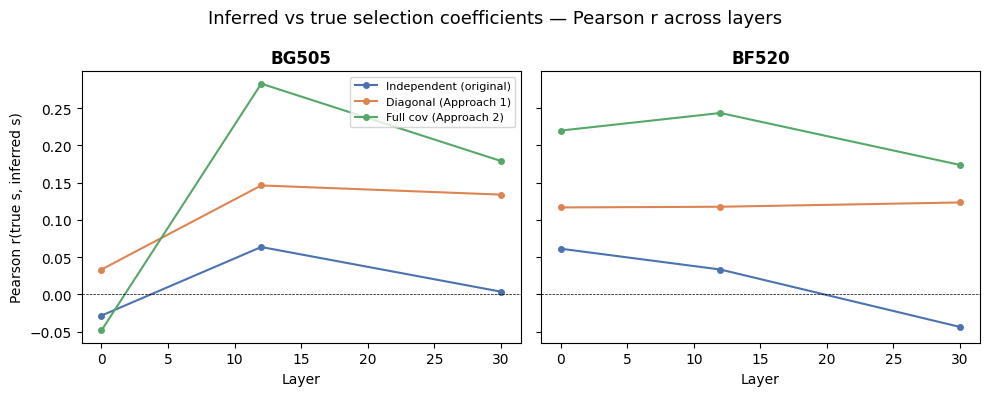

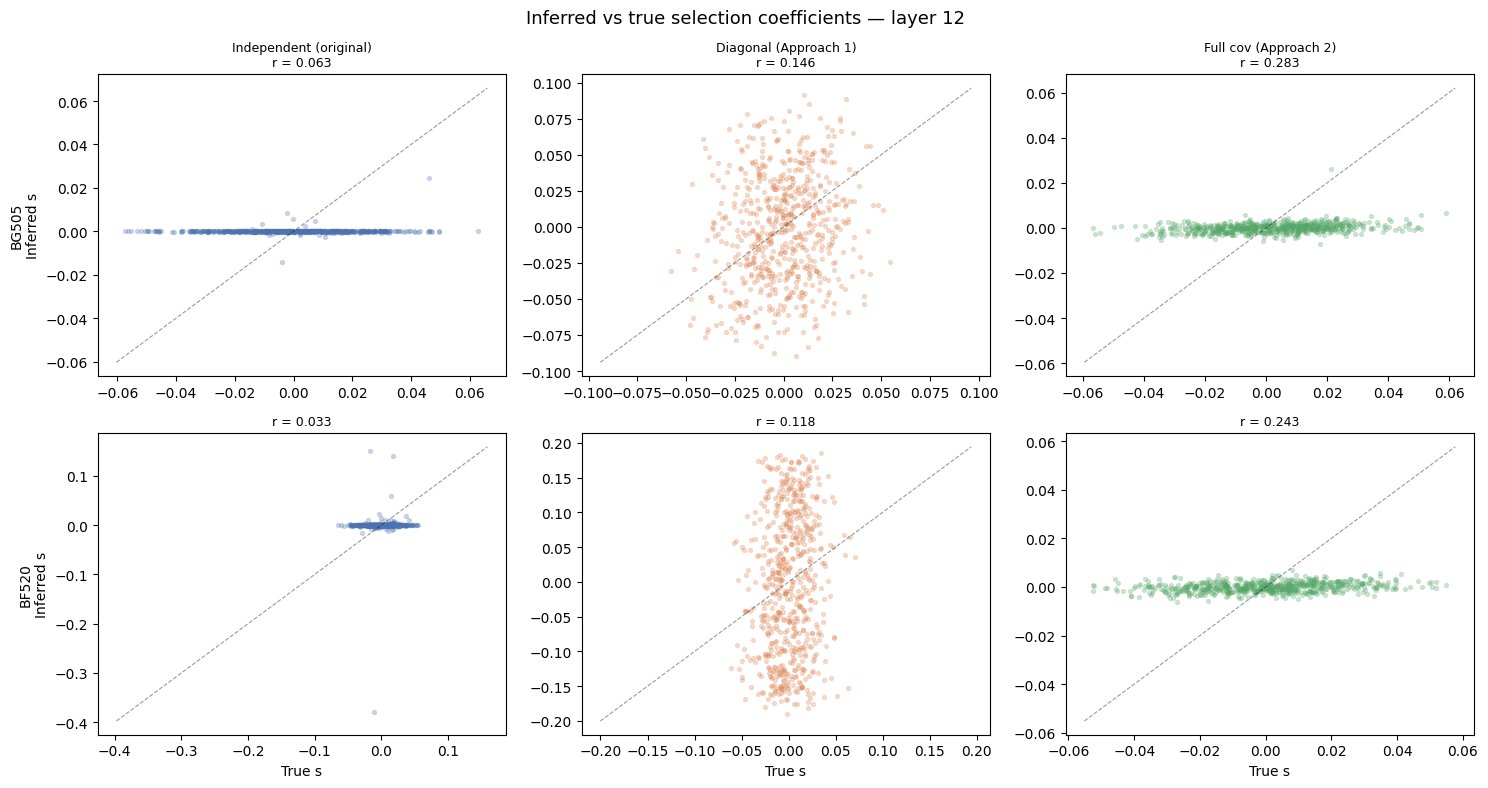

In [8]:
rep_layer = LAYERS_LIST[len(LAYERS_LIST) // 2]
print(f"Representative layer for scatter plots: {rep_layer}")

# Part 1: Pearson r vs layer, one panel per dataset
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5 * len(DATASETS), 4), sharey=True)
fig.suptitle("Inferred vs true selection coefficients — Pearson r across layers", fontsize=13)
for di, path_name in enumerate(DATASETS):
    ax = axes[di]
    for method in METHODS:
        ax.plot(LAYERS_LIST, r_s[method][path_name],
                marker='o', ms=4, lw=1.5,
                label=METHOD_LABELS[method], color=METHOD_COLORS[method])
    ax.set_title(path_name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Layer")
    ax.axhline(0, color='k', lw=0.5, ls='--')
    if di == 0:
        ax.set_ylabel("Pearson r(true s, inferred s)")
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Part 2: Scatter at representative layer — 3 datasets x 3 methods
fig, axes = plt.subplots(len(DATASETS), len(METHODS),
                         figsize=(5 * len(METHODS), 4 * len(DATASETS)))
fig.suptitle(f"Inferred vs true selection coefficients — layer {rep_layer}", fontsize=13)
for di, path_name in enumerate(DATASETS):
    for mi, method in enumerate(METHODS):
        ax = axes[di, mi]
        res       = SIM_ALL[method][path_name]
        true_s_d  = res[1]
        detailed  = res[2]
        if rep_layer not in true_s_d or rep_layer not in detailed:
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes, ha='center')
            continue
        s_true  = true_s_d[rep_layer].flatten()
        s_infer = detailed[rep_layer][1].flatten()
        mask    = ~np.isnan(s_infer)
        ax.scatter(s_true[mask], s_infer[mask],
                   alpha=0.25, s=8, color=METHOD_COLORS[method])
        r_val = pearsonr(s_true[mask], s_infer[mask]).statistic if mask.sum() > 1 else np.nan
        lims = [min(s_true[mask].min(), s_infer[mask].min()) * 1.05,
                max(s_true[mask].max(), s_infer[mask].max()) * 1.05]
        ax.plot(lims, lims, 'k--', lw=0.8, alpha=0.4)
        title_top = METHOD_LABELS[method] if di == 0 else ""
        r_str = f"r = {r_val:.3f}" if np.isfinite(r_val) else "r = nan"
        ax.set_title((title_top + ("\n" if title_top else "") + r_str).strip(), fontsize=9)
        if mi == 0:
            ax.set_ylabel(f"{path_name}\nInferred s")
        if di == len(DATASETS) - 1:
            ax.set_xlabel("True s")
plt.tight_layout()
plt.show()


### Figure 3: True vs inferred fitness

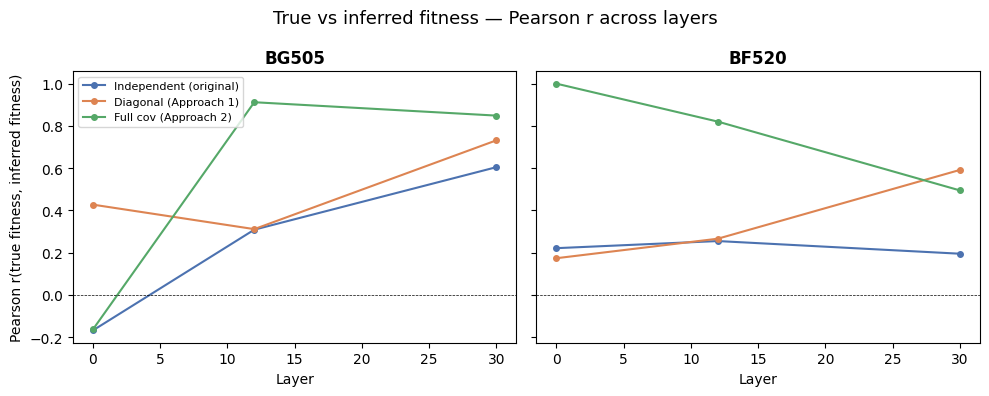

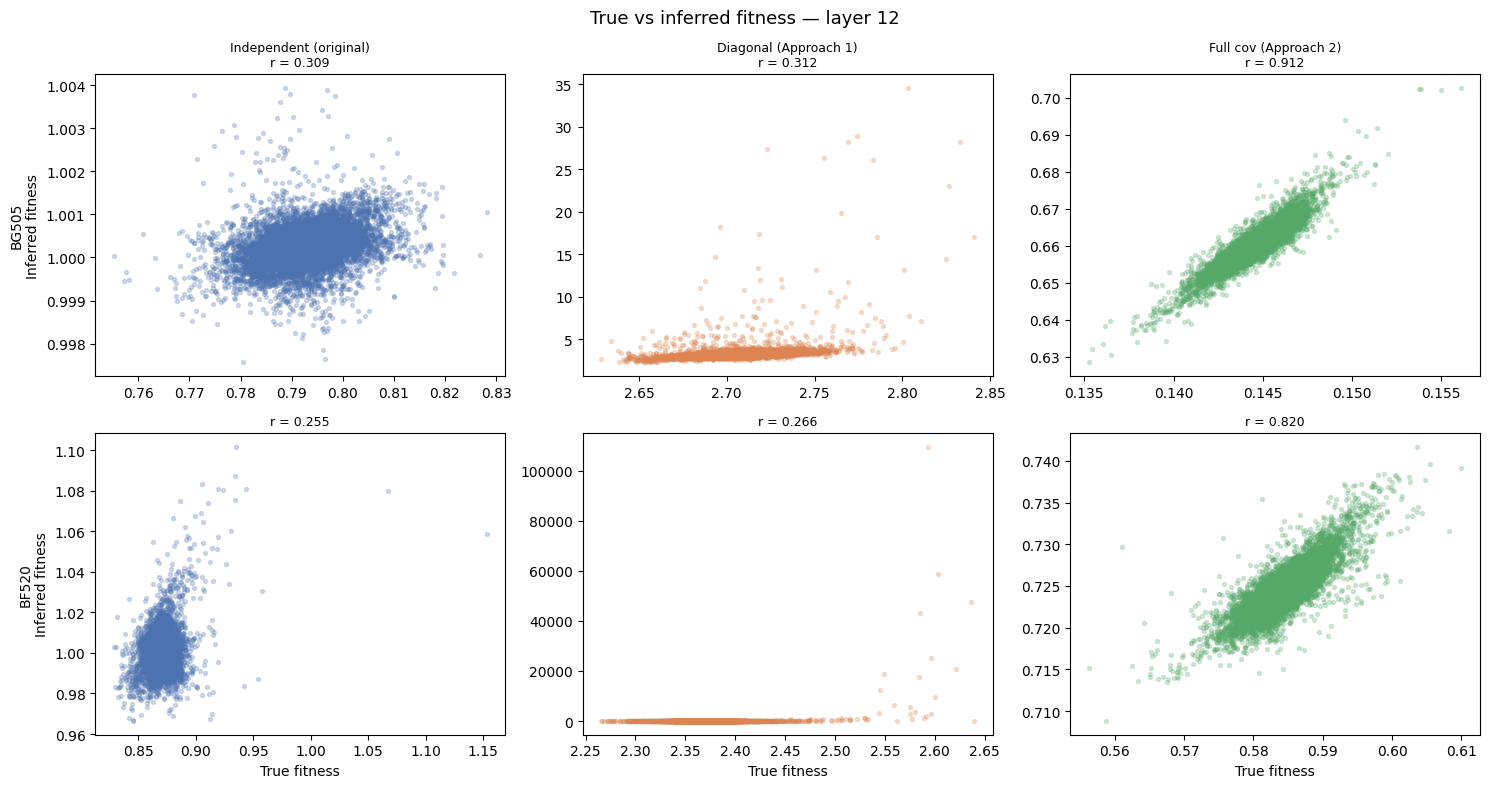

In [9]:
# Part 1: Pearson r vs layer
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5 * len(DATASETS), 4), sharey=True)
fig.suptitle("True vs inferred fitness — Pearson r across layers", fontsize=13)
for di, path_name in enumerate(DATASETS):
    ax = axes[di]
    for method in METHODS:
        ax.plot(LAYERS_LIST, r_fitness[method][path_name],
                marker='o', ms=4, lw=1.5,
                label=METHOD_LABELS[method], color=METHOD_COLORS[method])
    ax.set_title(path_name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Layer")
    ax.axhline(0, color='k', lw=0.5, ls='--')
    if di == 0:
        ax.set_ylabel("Pearson r(true fitness, inferred fitness)")
        ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Part 2: Scatter at representative layer
fig, axes = plt.subplots(len(DATASETS), len(METHODS),
                         figsize=(5 * len(METHODS), 4 * len(DATASETS)))
fig.suptitle(f"True vs inferred fitness — layer {rep_layer}", fontsize=13)
for di, path_name in enumerate(DATASETS):
    for mi, method in enumerate(METHODS):
        ax = axes[di, mi]
        key      = (path_name, rep_layer)
        detailed = SIM_ALL[method][path_name][2]
        true_fits = SIM_ALL[method][path_name][0]
        if key not in emb_cache or rep_layer not in detailed or rep_layer not in true_fits:
            ax.text(0.5, 0.5, 'no data', transform=ax.transAxes, ha='center')
            continue
        embeddings = emb_cache[key]
        s_joint    = detailed[rep_layer][1]
        s_clean    = np.where(np.isnan(s_joint), 0.0, s_joint)
        inf_fit    = np.exp(np.clip(embeddings @ s_clean, -50, 50))
        tru_fit    = true_fits[rep_layer]
        if len(inf_fit) == len(tru_fit) and np.all(np.isfinite(inf_fit)):
            ax.scatter(tru_fit, inf_fit, alpha=0.25, s=8, color=METHOD_COLORS[method])
            r_val = pearsonr(tru_fit, inf_fit).statistic
        else:
            r_val = np.nan
        r_str    = f"r = {r_val:.3f}" if np.isfinite(r_val) else "r = nan"
        title_top = METHOD_LABELS[method] if di == 0 else ""
        ax.set_title((title_top + ("\n" if title_top else "") + r_str).strip(), fontsize=9)
        if mi == 0:
            ax.set_ylabel(f"{path_name}\nInferred fitness")
        if di == len(DATASETS) - 1:
            ax.set_xlabel("True fitness")
plt.tight_layout()
plt.show()


### Figure 4: Summary comparison

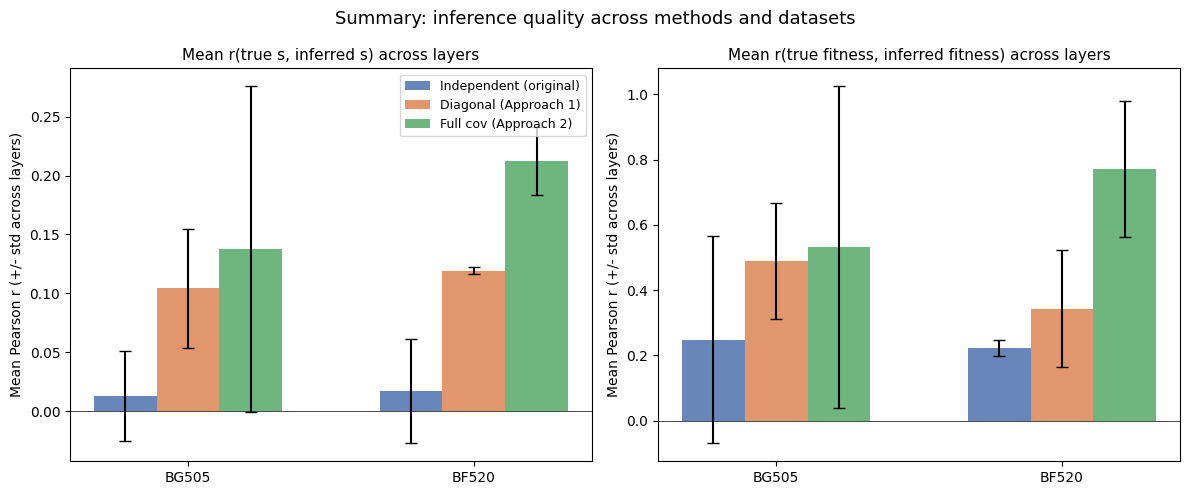


Summary table — mean Pearson r across layers:
Metric                              Method                     BG505         BF520       
--------------------------------------------------------------------------------------------
r(true s, inferred s)               independent                +0.013        +0.017      
                                    diagonal                   +0.104        +0.119      
                                    fullcov                    +0.138        +0.212      

r(true fitness, inferred fitness)   independent                +0.249        +0.224      
                                    diagonal                   +0.490        +0.344      
                                    fullcov                    +0.533        +0.772      



In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Summary: inference quality across methods and datasets", fontsize=13)

bar_w  = 0.22
n_meth = len(METHODS)
x      = np.arange(len(DATASETS))

for mi, method in enumerate(METHODS):
    offset   = (mi - n_meth / 2 + 0.5) * bar_w
    mean_rs  = [np.nanmean(r_s[method][p])       for p in DATASETS]
    std_rs   = [np.nanstd(r_s[method][p])        for p in DATASETS]
    mean_rf  = [np.nanmean(r_fitness[method][p]) for p in DATASETS]
    std_rf   = [np.nanstd(r_fitness[method][p])  for p in DATASETS]
    ax1.bar(x + offset, mean_rs, bar_w, yerr=std_rs, capsize=4,
            color=METHOD_COLORS[method], label=METHOD_LABELS[method], alpha=0.85)
    ax2.bar(x + offset, mean_rf, bar_w, yerr=std_rf, capsize=4,
            color=METHOD_COLORS[method], alpha=0.85)

for ax, title in [
    (ax1, "Mean r(true s, inferred s) across layers"),
    (ax2, "Mean r(true fitness, inferred fitness) across layers"),
]:
    ax.set_xticks(x)
    ax.set_xticklabels(DATASETS)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylabel("Mean Pearson r (+/- std across layers)")
    ax.set_title(title, fontsize=11)

ax1.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Print numeric summary
print("\nSummary table — mean Pearson r across layers:")
print(f"{'Metric':<35} {'Method':<25}" + "".join(f"  {p:<12}" for p in DATASETS))
print("-" * (35 + 25 + 16 * len(DATASETS)))
for metric, store in [("r(true s, inferred s)", r_s),
                      ("r(true fitness, inferred fitness)", r_fitness)]:
    for mi, method in enumerate(METHODS):
        row = f"{(metric if mi == 0 else ''):<35} {method:<25}"
        for p in DATASETS:
            v = np.nanmean(store[method][p])
            row += f"  {v:>+.3f}      "
        print(row)
    print()


Now just run the analysis

In [3]:
LAYERS = range(31)

# Full covariance matrix method seems to be the best

PATHS = {
    "comb":  comb_path,
    "BG505": bg_path,
    "BF520": bf_path,
}


all_results_fullcov = {}

for path_name, path in PATHS.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {path_name}  |  get_simulation_results, method=fullcov")
    print('='*60)

    res = get_simulation_results(
        n_gens=N_GENS,
        embedding_df_path=path,
        sel_func=SEL_FUNC,
        inference=RUN_INFERENCE,
        gamma_analysis=RUN_GAMMA,
        fitness=FITNESS_FN,
        save_every=SAVE_EVERY,
        layers=LAYERS,
        calc_error_bars=True,
        infer_ignored_dims=INFER_IGNORED,
        method="fullcov",
    )
    all_results_fullcov[path_name] = res  # detailed_selection_results
print("\nDone. Datasets completed:", list(all_results_fullcov.keys()))


Dataset: comb  |  get_simulation_results, method=fullcov
Running layer 0...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...
Running layer 1...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...
Running layer 2...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...
Running layer 3...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='fullcov')...
Running layer 4...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format..

In [4]:
# save the fullcov data for later analysis
output_file = "fullcov_all_results.pkl"
with open(output_file, "wb") as f:
    pickle.dump(all_results_fullcov, f)
print(f"\nFull covariance method all results saved to {output_file}")


Full covariance method all results saved to fullcov_all_results.pkl


In [ ]:
# load the data
all_results_fullcov = None
output_file = "fullcov_all_results.pkl"
with open(output_file, "rb") as f:
    all_results_fullcov = pickle.load(f)


In [5]:
LAYERS = range(0, 31, 6)

# Full covariance matrix method seems to be the best

PATHS = {
    "comb":  comb_path,
    "BG505": bg_path,
    "BF520": bf_path,
}


all_results_independent = {}

for path_name, path in PATHS.items():
    print(f"\n{'='*60}")
    print(f"Dataset: {path_name}  |  get_simulation_results, method=independent")
    print('='*60)

    
    try:
        res = get_simulation_results(
            n_gens=N_GENS,
            embedding_df_path=path,
            sel_func=SEL_FUNC,
            inference=RUN_INFERENCE,
            gamma_analysis=RUN_GAMMA,
            fitness=FITNESS_FN,
            save_every=SAVE_EVERY,
            layers=LAYERS,
            calc_error_bars=True,
            infer_ignored_dims=INFER_IGNORED,
            method="independent",
        )


        all_results_independent[path_name] = res  # all resuklts
    except Exception as e:
        print(f"Error processing {path_name} with independent method: {e}")
    
print("\nDone. Datasets completed:", list(all_results_independent.keys()))


Dataset: comb  |  get_simulation_results, method=independent
Running layer 0...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...
Running layer 6...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...
Running layer 12...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...
Running layer 18...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...


/Users/dylanwells/popDMS/esmDMS/popDMS.py:1499: RuntimeWarning: invalid value encountered in sqrt
  err_sub[r_idx] = np.sqrt(np.diag(np.linalg.inv(reg)))
/Users/dylanwells/popDMS/esmDMS/popDMS.py:1506: RuntimeWarning: invalid value encountered in sqrt
  s_joint_err_sub = np.sqrt(np.diag(np.linalg.inv(reg_joint)))


Running layer 24...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...
Running layer 30...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...

Dataset: BG505  |  get_simulation_results, method=independent
Running layer 0...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...
Error processing BG505 with independent method: list index out of range

Dataset: BF520  |  get_simulation_results, method=independent
Running layer 0...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated dat

/Users/dylanwells/popDMS/esmDMS/popDMS.py:1499: RuntimeWarning: invalid value encountered in sqrt
  err_sub[r_idx] = np.sqrt(np.diag(np.linalg.inv(reg)))
/Users/dylanwells/popDMS/esmDMS/popDMS.py:1506: RuntimeWarning: invalid value encountered in sqrt
  s_joint_err_sub = np.sqrt(np.diag(np.linalg.inv(reg_joint)))


Running layer 6...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...
Running layer 12...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...


...

/Users/dylanwells/popDMS/esmDMS/popDMS.py:1499: RuntimeWarning: invalid value encountered in sqrt
  err_sub[r_idx] = np.sqrt(np.diag(np.linalg.inv(reg)))
/Users/dylanwells/popDMS/esmDMS/popDMS.py:1506: RuntimeWarning: invalid value encountered in sqrt
  s_joint_err_sub = np.sqrt(np.diag(np.linalg.inv(reg_joint)))


Running layer 24...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...


/Users/dylanwells/popDMS/esmDMS/popDMS.py:1499: RuntimeWarning: invalid value encountered in sqrt
  err_sub[r_idx] = np.sqrt(np.diag(np.linalg.inv(reg)))
/Users/dylanwells/popDMS/esmDMS/popDMS.py:1506: RuntimeWarning: invalid value encountered in sqrt
  s_joint_err_sub = np.sqrt(np.diag(np.linalg.inv(reg_joint)))


Running layer 30...
Running simulation...
  Analyzing generation 30...
Transferring simulation data to inference dataframe format...
Running inference calculations on simulated data (method='independent')...

Done. Datasets completed: ['comb', 'BF520']


/Users/dylanwells/popDMS/esmDMS/popDMS.py:1499: RuntimeWarning: invalid value encountered in sqrt
  err_sub[r_idx] = np.sqrt(np.diag(np.linalg.inv(reg)))
/Users/dylanwells/popDMS/esmDMS/popDMS.py:1506: RuntimeWarning: invalid value encountered in sqrt
  s_joint_err_sub = np.sqrt(np.diag(np.linalg.inv(reg_joint)))


In [6]:
# save the full results for later analysis
output_file = "independent_all_results.pkl"
with open(output_file, "wb") as f:
    pickle.dump(all_results_independent, f)
print(f"\nIndependent method all results saved to {output_file}")



Independent method all results saved to independent_all_results.pkl


In [5]:
from scipy.stats import spearmanr
from esmdmsfunctions import (
    load_final_df,
    calculate_fitness_exp,
    calculate_fitness_plus1,
    comp_inf_vs_real_fits,
)

